In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set a beautiful, professional theme for the judges
sns.set_theme(style="darkgrid", context="talk")
plt.rcParams['figure.figsize'] = (14, 6)

# 1. Generate 50 points of synthetic "Raw CSI" (Cognitive Strain Index)
np.random.seed(42)
time_steps = np.arange(50)

# Simulate a user baseline (around 0.2 to 0.4) with normal noise
baseline_csi = np.random.normal(loc=0.3, scale=0.05, size=50)

# Inject a "Masking" spike at step 20 (sudden erratic typing)
baseline_csi[20] = 0.85

# Inject a slow "Night Spiral" deterioration from step 35 to 50
spiral = np.linspace(0, 0.5, 15)
baseline_csi[35:] += spiral
raw_csi = np.clip(baseline_csi, 0, 1)

print("✅ Synthetic session data generated.")

✅ Synthetic session data generated.


In [2]:
# 2. Replicate our backend math to show the judges exactly how it works
alpha = 0.3 # Our EMA smoothing factor
ema_risk = np.zeros(50)
z_scores = np.zeros(50)

ema_risk[0] = raw_csi[0]

for i in range(1, 50):
    # EMA Calculation (Temporal Smoothing)
    ema_risk[i] = (alpha * raw_csi[i]) + ((1 - alpha) * ema_risk[i-1])
    
    # Z-Score Calibration (Rolling Baseline)
    if i > 5:
        history = raw_csi[max(0, i-15):i] # Look at last 15 steps
        mean = np.mean(history)
        std = np.std(history) + 1e-5
        z_scores[i] = (raw_csi[i] - mean) / std
    else:
        z_scores[i] = 0

print("✅ Temporal Math & Baseline Calibration computed.")

✅ Temporal Math & Baseline Calibration computed.


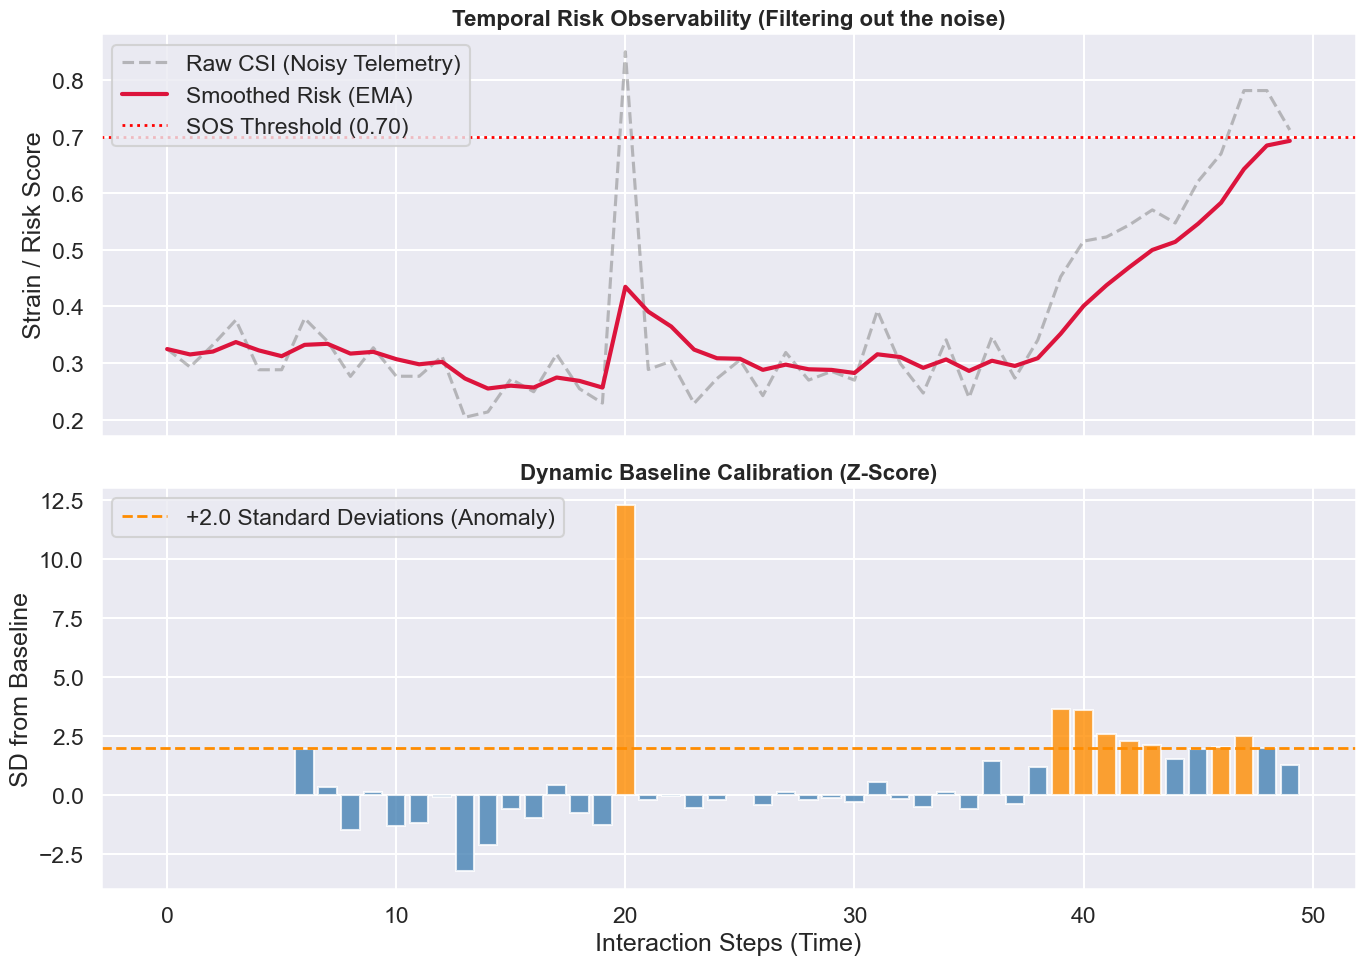

In [3]:
# 3. Plot 1: Raw Noise vs. Smoothed Clinical Risk
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Top Plot: CSI vs EMA
ax1.plot(time_steps, raw_csi, color='gray', alpha=0.5, linestyle='--', label='Raw CSI (Noisy Telemetry)')
ax1.plot(time_steps, ema_risk, color='crimson', linewidth=3, label='Smoothed Risk (EMA)')
ax1.axhline(y=0.70, color='red', linestyle=':', linewidth=2, label='SOS Threshold (0.70)')
ax1.set_title("Temporal Risk Observability (Filtering out the noise)", fontsize=16, fontweight='bold')
ax1.set_ylabel("Strain / Risk Score")
ax1.legend(loc='upper left')

# Bottom Plot: The Z-Score Anomaly Radar
ax2.bar(time_steps, z_scores, color=np.where(z_scores > 2.0, 'darkorange', 'steelblue'), alpha=0.8)
ax2.axhline(y=2.0, color='darkorange', linestyle='--', linewidth=2, label='+2.0 Standard Deviations (Anomaly)')
ax2.set_title("Dynamic Baseline Calibration (Z-Score)", fontsize=16, fontweight='bold')
ax2.set_xlabel("Interaction Steps (Time)")
ax2.set_ylabel("SD from Baseline")
ax2.legend(loc='upper left')

plt.tight_layout()
plt.show()